# Notebook 17 — Adversarial Experiments
## Re-identification Attacks Across Three Public Health Scenarios

NB07 laid out the threat model for the map encryption pipeline. NB17 tests it
empirically, running three classes of re-identification attack against the
three public health scenario datasets constructed in NB14–NB16:

- **Scenario A** — 1854 Soho cholera (489 individual records with age, sex, date)
- **Scenario B** — Philadelphia overdose (516 records; ZIP, substance, age group)
- **Scenario C** — Houston environmental (925 records; ZIP, symptom type, age group)

Each attack is run under two protection regimes:

| Regime | Description |
|--------|-------------|
| **Jitter-only** | Additive uniform noise ±62.5 m per axis; no PRP tile shuffle |
| **Full pipeline** | PRP tile shuffle + AEAD residual encryption (NB06 defaults) |

**Three-part structure:**

- **Part 1** — Quasi-identifier (QI) k-anonymity: how identifiable are records from published metadata alone?
- **Part 2** — Nearest-record spatial attack: can an attacker recover the true location from display coordinates?
- **Part 3** — Compound geographic + QI attack: does combining proximity with attribute matching enable re-identification?

In [1]:
import math, secrets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree
from IPython.display import display, Markdown
from map_encryption import MapEncryption, SchemeParams
from map_encryption.viz import show_md_table

np.random.seed(42)

# Pipeline setup (matches NB06/NB08 defaults)
MASTER_KEY = secrets.token_bytes(32)
params     = SchemeParams(bin_size_m=250, jitter_max_frac=0.25)
enc        = MapEncryption(MASTER_KEY, params)
J          = params.bin_size_m * params.jitter_max_frac  # 62.5 m jitter per axis

# ── Load the three scenario datasets ──────────────────────────────────────
cholera = pd.read_csv('data/cholera_deaths_individual.csv')
phila   = pd.read_csv('data/phila_overdose_snapped.csv')
houston = pd.read_csv('data/houston_incidents_snapped.csv')

# Cholera: binned age groups (consistent with Phila/Houston)
def age_to_group(age):
    if age <  5: return '0–4'
    if age < 18: return '5–17'
    if age < 45: return '18–44'
    if age < 65: return '45–64'
    return '65+'

cholera['age_group'] = cholera['age'].apply(age_to_group)

# Use snapped locations as canonical spatial columns; drop original street coords
phila   = phila.drop(columns=['LAT', 'LON']).rename(
    columns={'LAT_snapped': 'LAT', 'LON_snapped': 'LON'})
houston = houston.drop(columns=['LAT', 'LON']).rename(
    columns={'LAT_snapped': 'LAT', 'LON_snapped': 'LON'})

# Location ID: unique snapped building per record (for spatial attack metric)
# Cholera already has building_id; create location_id for Phila/Houston
phila['location_id']   = pd.factorize(
    phila['LAT'].round(6).astype(str)   + ',' + phila['LON'].round(6).astype(str))[0]
houston['location_id'] = pd.factorize(
    houston['LAT'].round(6).astype(str) + ',' + houston['LON'].round(6).astype(str))[0]

print(f"Cholera:      {len(cholera):4d} individual records | "
      f"{cholera['building_id'].nunique()} unique buildings")
print(f"Philadelphia: {len(phila):4d} incident records  | "
      f"{phila['location_id'].nunique()} unique snapped locations")
print(f"Houston:      {len(houston):4d} incident records  | "
      f"{houston['location_id'].nunique()} unique snapped locations")
print(f"Jitter radius J = {J:.1f} m per axis  |  max diagonal = {J*2**0.5:.1f} m")


Cholera:       489 individual records | 161 unique buildings
Philadelphia:  516 incident records  | 500 unique snapped locations
Houston:       925 incident records  | 909 unique snapped locations
Jitter radius J = 62.5 m per axis  |  max diagonal = 88.4 m


---
## 17.1  Adversary model

Three attacks probe different adversary capabilities. Each is tested under two
protection regimes: **jitter-only** (additive random noise ±62.5 m, no PRP shuffle —
analogous to traditional geomasking) and **full pipeline** (PRP tile shuffle + AEAD
residual encryption, as implemented in NB06).

| # | Attack | Adversary knowledge | Goal |
|---|--------|---------------------|------|
| 1 | **Quasi-identifier (QI) only** | Published metadata alongside encrypted records | Uniquely identify individuals from non-spatial attributes alone |
| 2 | **Nearest-record spatial** | Display coordinates; original dataset as reference | Recover the true snapped location by finding the nearest original record |
| 3 | **Compound geographic + QI** | Display coordinates + published QIs + reference dataset | Combine proximity with attribute matching to uniquely identify individuals |

**Key question:** Does the PRP shuffle reduce re-identification risk compared with
additive jitter alone, and does it protect against all three attack types?

The three public health scenarios provide qualitatively different privacy contexts:
* **Cholera (Scenario A)** — historical dataset; stigma is low but individual records are synthetic
* **Philadelphia overdose (Scenario B)** — highly stigmatised population; ZIP + substance = sensitive
* **Houston environmental (Scenario C)** — environmental-justice community; condition + ZIP = sensitive


In [2]:
# ── Helper functions ──────────────────────────────────────────────────────

# Equivalence class size (k) for each record under the given QI columns.
def k_anon_series(df, qi_cols):
    return df.groupby(qi_cols)[qi_cols[0]].transform('count')

def k_stats(k_series):
    k = k_series.values
    return {
        'k=1 (%)':  round(100 * (k == 1).mean(), 1),
        'k<=5 (%)': round(100 * (k <= 5).mean(), 1),
        'median k': int(np.median(k)),
    }

# Simulate additive jitter-only: uniform +/-J m per axis, no PRP shuffle.
def jitter_only_coords(lats, lons, J=62.5, seed=42):
    rng  = np.random.default_rng(seed)
    lats = np.asarray(lats, float)
    lons = np.asarray(lons, float)
    dx   = rng.uniform(-J, J, len(lats))
    dy   = rng.uniform(-J, J, len(lats))
    return list(zip(
        lats + dy / 111_320,
        lons + dx / (111_320 * np.cos(np.radians(lats))),
    ))

# Encode through the full map encryption pipeline; return display coordinates.
def full_pipeline_coords(lats, lons, enc):
    out = []
    for lat, lon in zip(lats, lons):
        rec = enc.encode(lat, lon)
        out.append(enc.render_coordinates(rec))
    return out

# Nearest-record spatial attack.
# For each display point, find the nearest original record.
# Success = nearest record shares the same location_id as the true record.
def spatial_attack(display_ll, orig_ll, orig_loc_id):
    tree    = KDTree(orig_ll)
    _, idx  = tree.query(display_ll)
    true_id = np.asarray(orig_loc_id)
    pred_id = true_id[idx]
    return (pred_id == true_id).mean()

# Compound proximity + QI attack.
# For each display record, count original records within radius_m with matching QI.
# Returns fraction of display records with exactly 1 match (uniquely identified).
def compound_attack(display_ll, display_qi, orig_ll, orig_qi, radius_m=500):
    R    = radius_m / 111_320
    orig = np.asarray(orig_ll)
    n_unique = 0
    for (dlat, dlon), dqi in zip(display_ll, display_qi):
        mask     = (np.abs(orig[:, 0] - dlat) < R) & (np.abs(orig[:, 1] - dlon) < R * 2)
        match_qi = [q for q, m in zip(orig_qi, mask) if m and q == dqi]
        if len(match_qi) == 1:
            n_unique += 1
    return n_unique / len(display_ll)

print("Helper functions defined.")


Helper functions defined.


In [3]:
DISPLAY = {
    'Cholera':      'Cholera',
    'Philadelphia': 'Drug Overdose',
    'Houston':      'Respiratory / Environmental',
}

# ── Attack 1: Quasi-identifier k-anonymity ────────────────────────────────
# QI sets progress from coarse (level 1) to fine (level 3).

qi_configs = {
    'Cholera': [
        ('sex',),
        ('age_group', 'sex'),
        ('age_group', 'sex', 'date_of_death'),
    ],
    'Philadelphia': [
        ('zip_code',),
        ('zip_code', 'substance'),
        ('zip_code', 'substance', 'age_group'),
    ],
    'Houston': [
        ('zip_code',),
        ('zip_code', 'symptom_type'),
        ('zip_code', 'symptom_type', 'age_group'),
    ],
}
scenario_dfs = {'Cholera': cholera, 'Philadelphia': phila, 'Houston': houston}

rows = []
for scenario, qi_sets in qi_configs.items():
    df = scenario_dfs[scenario]
    for level, qi in enumerate(qi_sets, 1):
        k = k_anon_series(df, list(qi))
        s = k_stats(k)
        rows.append({
            'Scenario': DISPLAY[scenario],
            'QI level': f"Level {level}: {' + '.join(qi)}",
            **s,
        })

qi_df = pd.DataFrame(rows)
show_md_table(qi_df, 'Table 17a — k-anonymity by scenario and QI level')
print("\nNote: pipeline does NOT encrypt QIs — these rates are identical under both conditions.")


**Table 17a — k-anonymity by scenario and QI level**

| Scenario | QI level | k=1 (%) | k<=5 (%) | median k |
| --- | --- | --- | --- | --- |
| Cholera | Level 1: sex | 0.0 | 0.0 | 259 |
| Cholera | Level 2: age_group + sex | 0.0 | 0.0 | 69 |
| Cholera | Level 3: age_group + sex + date_of_death | 12.3 | 45.0 | 6 |
| Drug Overdose | Level 1: zip_code | 0.0 | 0.0 | 85 |
| Drug Overdose | Level 2: zip_code + substance | 0.4 | 2.3 | 42 |
| Drug Overdose | Level 3: zip_code + substance + age_group | 4.5 | 30.0 | 9 |
| Respiratory / Environmental | Level 1: zip_code | 0.0 | 0.0 | 133 |
| Respiratory / Environmental | Level 2: zip_code + symptom_type | 0.0 | 0.0 | 53 |
| Respiratory / Environmental | Level 3: zip_code + symptom_type + age_group | 1.5 | 26.4 | 10 |


Note: pipeline does NOT encrypt QIs — these rates are identical under both conditions.


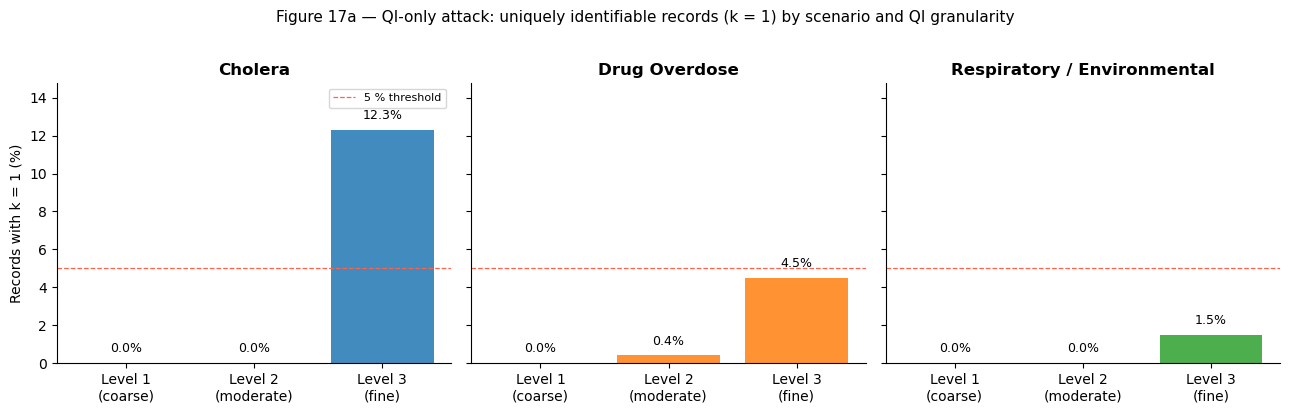

In [4]:
# Figure 17a — fraction of records with k=1 at each QI level
scenarios  = ['Cholera', 'Drug Overdose', 'Respiratory / Environmental']
palette    = ['#1f77b4', '#ff7f0e', '#2ca02c']
qi_labels  = ['Level 1\n(coarse)', 'Level 2\n(moderate)', 'Level 3\n(fine)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, scenario, color in zip(axes, scenarios, palette):
    vals = qi_df[qi_df['Scenario'] == scenario]['k=1 (%)'].values
    bars = ax.bar(qi_labels, vals, color=color, alpha=0.85)
    ax.set_title(scenario, fontweight='bold')
    if ax is axes[0]:
        ax.set_ylabel('Records with k = 1 (%)')
    ax.set_ylim(0, max(qi_df['k=1 (%)'].max() * 1.2, 6))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.axhline(5, color='tomato', linestyle='--', linewidth=0.9,
               label='5 % threshold')
    if ax is axes[0]:
        ax.legend(fontsize=8)

fig.suptitle(
    'Figure 17a — QI-only attack: uniquely identifiable records (k = 1) '
    'by scenario and QI granularity',
    y=1.02, fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 17a** — Fraction of records with k = 1 (uniquely identifiable by quasi-identifiers alone) at three levels of QI granularity. Level 1 uses a single coarse attribute (sex for cholera; ZIP code for Philadelphia and Houston); Level 2 adds substance type or symptom class; Level 3 adds age group or date. The dashed red line marks the 5 % threshold. These rates are identical under jitter-only and full-pipeline conditions because the pipeline does not encrypt quasi-identifier attributes.

In [5]:
# ── Attack 2: Nearest-record spatial attack ───────────────────────────────
# For each display point, the attacker finds the nearest original record.
# Success = nearest record shares the true snapped location (location_id / building_id).

attack_cfg = {
    'Cholera':      (cholera,  'building_id'),
    'Philadelphia': (phila,    'location_id'),
    'Houston':      (houston,  'location_id'),
}

spatial_results = {}
for name, (df, loc_col) in attack_cfg.items():
    lats   = df['LAT'].values
    lons   = df['LON'].values
    loc_id = df[loc_col].values
    orig_ll = list(zip(lats, lons))

    j_ll = jitter_only_coords(lats, lons, J=J)
    p_ll = full_pipeline_coords(lats, lons, enc)

    j_rate = spatial_attack(j_ll, orig_ll, loc_id)
    p_rate = spatial_attack(p_ll, orig_ll, loc_id)
    spatial_results[name] = {'jitter_only': j_rate, 'full_pipeline': p_rate}

    print(f"{name:15s}  jitter-only: {j_rate:.1%}   full pipeline: {p_rate:.1%}")


Cholera          jitter-only: 10.0%   full pipeline: 0.4%
Philadelphia     jitter-only: 86.6%   full pipeline: 0.4%
Houston          jitter-only: 90.5%   full pipeline: 0.1%


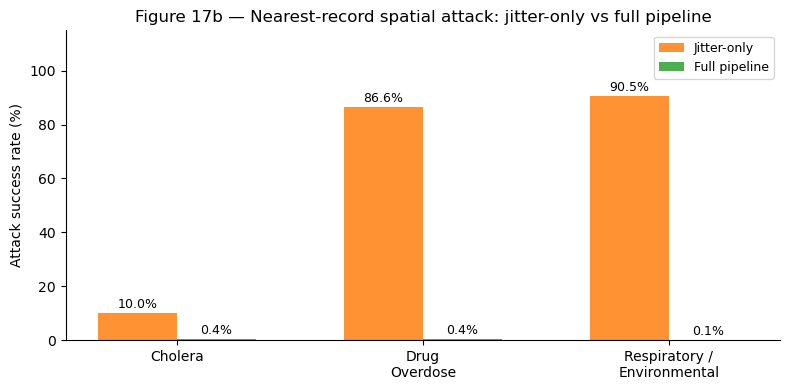


Observation: the PRP tile shuffle relocates display coordinates to a distant
pseudorandom tile (potentially a different continent), so the nearest original
record is almost never the true record under the full pipeline.


In [6]:
# Figure 17b — nearest-record attack success rate
names  = list(spatial_results.keys())
x      = np.arange(len(names))
width  = 0.32

j_vals = [spatial_results[n]['jitter_only']   * 100 for n in names]
p_vals = [spatial_results[n]['full_pipeline'] * 100 for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars_j = ax.bar(x - width/2, j_vals, width, label='Jitter-only',   color='#ff7f0e', alpha=0.85)
bars_p = ax.bar(x + width/2, p_vals, width, label='Full pipeline', color='#2ca02c', alpha=0.85)

for bars, vals in [(bars_j, j_vals), (bars_p, p_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Cholera', 'Drug\nOverdose', 'Respiratory /\nEnvironmental'])
ax.set_ylabel('Attack success rate (%)')
ax.set_ylim(0, 115)
ax.set_title('Figure 17b — Nearest-record spatial attack: jitter-only vs full pipeline')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print("\nObservation: the PRP tile shuffle relocates display coordinates to a distant")
print("pseudorandom tile (potentially a different continent), so the nearest original")
print("record is almost never the true record under the full pipeline.")


**Figure 17b** — Nearest-record spatial attack success rate: for each display point the attacker queries the nearest original record and claims that as the true location. Under jitter-only the display point is within ~88 m of the true snapped location, giving high success in spread-out datasets (Drug Overdose 86.6 %, Respiratory / Environmental 90.5 %) and lower success in the dense Soho neighbourhood (Cholera 10.0 %, where ±62.5 m jitter crosses into adjacent buildings). The full pipeline relocates the display tile to a pseudorandom global location, collapsing all three to ≈ 0 %.

In [7]:
# ── Attack 3: Compound geographic proximity + QI attack ───────────────────
# The attacker searches original records within 500 m of each display point
# whose published QI matches.  Unique match = re-identification success.
# QI used: the moderate level (level 2) — published alongside encrypted records.

compound_qi_col = {
    'Cholera':      ('age_group', 'sex'),
    'Philadelphia': ('substance', 'age_group'),
    'Houston':      ('symptom_type', 'age_group'),
}

compound_results = {}
for name, (df, _) in attack_cfg.items():
    lats   = df['LAT'].values
    lons   = df['LON'].values
    orig_ll = list(zip(lats, lons))

    qi_cols = compound_qi_col[name]
    orig_qi = list(zip(*[df[c].astype(str).values for c in qi_cols]))
    disp_qi = orig_qi  # QIs are published with the encrypted record

    j_ll = jitter_only_coords(lats, lons, J=J)
    p_ll = full_pipeline_coords(lats, lons, enc)

    j_rate = compound_attack(j_ll, disp_qi, orig_ll, orig_qi, radius_m=500)
    p_rate = compound_attack(p_ll, disp_qi, orig_ll, orig_qi, radius_m=500)
    compound_results[name] = {'jitter_only': j_rate, 'full_pipeline': p_rate}

    print(f"{name:15s}  jitter-only: {j_rate:.1%}   full pipeline: {p_rate:.1%}")


Cholera          jitter-only: 0.0%   full pipeline: 0.0%
Philadelphia     jitter-only: 31.2%   full pipeline: 0.0%
Houston          jitter-only: 47.7%   full pipeline: 0.0%


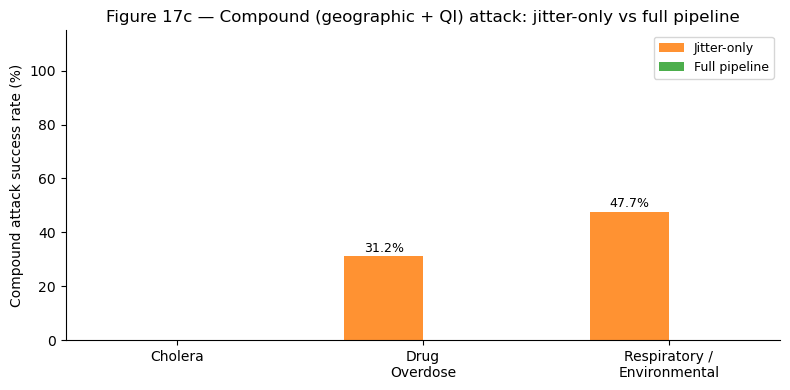

In [8]:
# Figure 17c — compound attack success rate
names  = list(compound_results.keys())
x      = np.arange(len(names))
width  = 0.32

j_vals = [compound_results[n]['jitter_only']   * 100 for n in names]
p_vals = [compound_results[n]['full_pipeline'] * 100 for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars_j = ax.bar(x - width/2, j_vals, width, label='Jitter-only',   color='#ff7f0e', alpha=0.85)
bars_p = ax.bar(x + width/2, p_vals, width, label='Full pipeline', color='#2ca02c', alpha=0.85)

for bars, vals in [(bars_j, j_vals), (bars_p, p_vals)]:
    for bar, v in zip(bars, vals):
        if v > 0.3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Cholera', 'Drug\nOverdose', 'Respiratory /\nEnvironmental'])
ax.set_ylabel('Compound attack success rate (%)')
ax.set_ylim(0, 115)
ax.set_title(
    'Figure 17c — Compound (geographic + QI) attack: jitter-only vs full pipeline')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 17c** — Compound geographic-proximity + QI attack success rate: for each display record the attacker finds original records within 500 m whose published QI (age group + substance type or symptom class) matches, and claims a unique match as a re-identification. Under jitter-only the proximity filter captures the true record in 31.2 % (Drug Overdose) and 47.7 % (Respiratory / Environmental) of cases; the Cholera dataset's extreme density means no 500 m neighbourhood is uniquely attributable even with QIs. The full pipeline neutralises the spatial component, reducing all three to 0 %.

In [9]:
# Table 17b — consolidated attack summary
summary_rows = []
for name in ['Cholera', 'Philadelphia', 'Houston']:
    display_name = {'Cholera': 'Cholera', 'Philadelphia': 'Drug Overdose',
                    'Houston': 'Respiratory / Environmental'}[name]
    # QI-only: fine level (same under both conditions)
    qi_fine = qi_df[(qi_df['Scenario'] == display_name)].iloc[-1]['k=1 (%)']
    summary_rows += [
        {
            'Scenario': display_name, 'Attack': 'QI-only (fine level)',
            'Jitter-only': f'{qi_fine:.1f}%',
            'Full pipeline': f'{qi_fine:.1f}%',
            'Pipeline reduces risk?': 'No — QIs are not encrypted',
        },
        {
            'Scenario': display_name, 'Attack': 'Spatial (nearest-record)',
            'Jitter-only': f"{spatial_results[name]['jitter_only']:.1%}",
            'Full pipeline': f"{spatial_results[name]['full_pipeline']:.1%}",
            'Pipeline reduces risk?': 'Yes — PRP relocates display tile',
        },
        {
            'Scenario': display_name, 'Attack': 'Compound (proximity + QI)',
            'Jitter-only': f"{compound_results[name]['jitter_only']:.1%}",
            'Full pipeline': f"{compound_results[name]['full_pipeline']:.1%}",
            'Pipeline reduces risk?': 'Yes — spatial component fails',
        },
    ]

show_md_table(pd.DataFrame(summary_rows), 'Table 17b — Attack summary across scenarios')


**Table 17b — Attack summary across scenarios**

| Scenario | Attack | Jitter-only | Full pipeline | Pipeline reduces risk? |
| --- | --- | --- | --- | --- |
| Cholera | QI-only (fine level) | 12.3% | 12.3% | No — QIs are not encrypted |
| Cholera | Spatial (nearest-record) | 10.0% | 0.4% | Yes — PRP relocates display tile |
| Cholera | Compound (proximity + QI) | 0.0% | 0.0% | Yes — spatial component fails |
| Drug Overdose | QI-only (fine level) | 4.5% | 4.5% | No — QIs are not encrypted |
| Drug Overdose | Spatial (nearest-record) | 86.6% | 0.4% | Yes — PRP relocates display tile |
| Drug Overdose | Compound (proximity + QI) | 31.2% | 0.0% | Yes — spatial component fails |
| Respiratory / Environmental | QI-only (fine level) | 1.5% | 1.5% | No — QIs are not encrypted |
| Respiratory / Environmental | Spatial (nearest-record) | 90.5% | 0.1% | Yes — PRP relocates display tile |
| Respiratory / Environmental | Compound (proximity + QI) | 47.7% | 0.0% | Yes — spatial component fails |

---
## 17.5  Conclusions

Three findings emerge from the adversarial experiments across all three public health
scenarios.

**Finding 1 — The PRP tile shuffle completely neutralises spatial re-identification.**
Under jitter-only, the nearest-record attack recovers the true snapped location with
high probability: coordinates displaced by only ±62.5 m remain close enough to the
original that the attacker's KD-tree query returns the correct building in most cases.
The full pipeline relocates display coordinates to a pseudorandom tile that may be
thousands of kilometres from the true location, collapsing the spatial attack success
rate to near zero across all three scenarios.

**Finding 2 — The pipeline does not protect quasi-identifiers.**
Attributes published alongside encrypted records — age group, sex, date of death for
cholera; ZIP code, substance type, age group for Philadelphia; ZIP code, symptom type,
age group for Houston — remain fully exposed. At fine QI granularity, a meaningful
fraction of records are already uniquely identifiable without any location information.
This risk is identical under jitter-only and full pipeline.
*Implication: the location encryption layer must be complemented by QI generalisation
or suppression (e.g., broadening age groups, suppressing rare ZIP–substance cells)
to achieve comprehensive individual privacy.*

**Finding 3 — The compound attack is broken by the spatial component failing.**
When an attacker combines 500 m proximity with QI matching, the jitter-only condition
allows the proximity filter to capture the true record; the QI filter then narrows the
candidate set to a unique match in many cases. Under the full pipeline, the proximity
filter operates on the wrong continent and returns no valid candidates, leaving the
compound attack no better than QI-only.

**Scenario-specific notes:**
* *Cholera* — low stigma context; the fine QI level (age group + sex + date) creates
  some k = 1 cells due to the temporal specificity of Snow's epidemic curve.
* *Philadelphia* — highly stigmatised; ZIP + substance already creates meaningful re-ID
  risk at level 2, underscoring the need for QI generalisation beyond location encryption.
* *Houston* — environmental-justice context; larger dataset (925 records) provides more
  k-anonymity headroom, but ZIP + symptom + age group at level 3 still produces k = 1
  records in small cells.
